# Main usage of Novae

This tutorial shows how to load a Novae model, apply it to your spatial data, and plot results. We show Noave's usage for spatial data with single-cell resolution (e.g., Xenium, MERSCOPE), but we will also soon make a tutorial for spot resolution data (e.g., Visium).

Make sure you have installed Novae, e.g. using `pip install novae`, as detailed in the [installation guide](../../getting_started).


In [1]:
import novae

## Create and process your AnnData object(s)

Novae's input is one or multiple [`AnnData`](https://anndata.readthedocs.io/en/latest/) object(s). Having multiple `AnnData` objects can be useful when you have multiple gene panels, or when you don't want to concatenate your slides. See [here](../input_modes) for more details on all four possible input modes for Novae.

For this tutorial, we first show an example using one `AnnData` object representing a colon slide. We load it with the [`load_dataset`](../../api/data/#novae.load_dataset) function.


In [2]:
adata = novae.load_dataset(tissue="colon", species="human", pattern=".*P2.*")[0]
adata

[INFO] (novae.data._load._hf) Found 1 h5ad file(s) matching the filters.


AnnData object with n_obs × n_vars = 340837 × 422
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'slide_id', 'technology'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'log1p', 'neighbors', 'spatial_neighbors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

Then, **preprocessing is not mandatory**, as Novae can handle it automatically. Here is some extra information:

- You can have either "log1p data" or "raw counts" in `adata.X`. In the latter case, Novae will preprocess it and save the counts in `adata.obsm`.
- We automatically select the genes that Novae should use. We use the highly variable genes (or eventually other genes, if not enough HVG).

> NB: You can disable the automatic preprocessing with `novae.settings.auto_preprocessing = False`


## One-slide inference


### Compute the cells neighbors

Novae runs on graphs of cells connected by physical proximity. To do so, we use [`novae.spatial_neighbors`](../../api/utils/#novae.spatial_neighbors), which will connect the cells based on their locations (in `adata.obsm["spatial"]`).

Here, we use `radius=80` to drop edges longer than 80 microns (optional).


In [5]:
# if you have multiple samples in the same adata object, specify `slide_key`
novae.spatial_neighbors(adata, radius=80)

[INFO] (novae.utils._build) Computing graph on 340,837 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)


We can also show the graph of connectivities, which is a good quality control. Nodes in red are cells that are connected to very few other cells (`ngh_threshold=2`, by default). In particular:

1. You should have a relatively low amount of "red" cells. If so, decrease the `radius` parameter.
2. Regions that are far apart should not be connected. If so, increase the `radius` parameter.

💡 If the graph is not looking right, check the docs of [`novae.spatial_neighbors`](../../api/utils/#novae.spatial_neighbors) to adapt it.


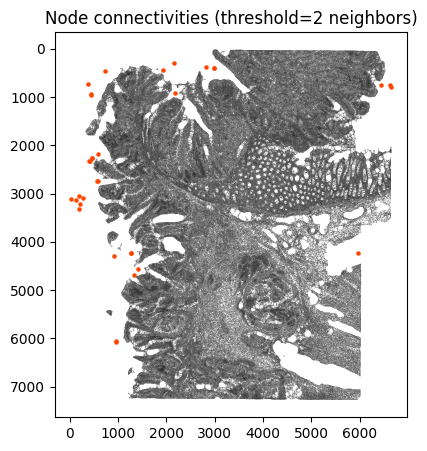

In [6]:
novae.plot.connectivities(adata)

### Use a pretrained model

Now, we need to load a pretrained Novae model.

Since we have a human colon slide, we load the `"prism-oncology/novae-human-0"` model, which can be used on any human tissue for spatial data with single-cell resolution. Other model names can be found [here](https://huggingface.co/collections/prism-oncology/novae) (spot-resolution models, e.g., for Visium data, will come soon).

> ⚠️ If you have `novae<1.0.5`, you'll not be able to load `prism-oncology/novae-human-0`, as we renamed recently our Hugging Face organization. Either upgrade novae, or use `MICS-Lab/novae-human-0` instead.


In [3]:
model = novae.Novae.from_pretrained("prism-oncology/novae-human-0")
model

Novae model
   ├── Known genes: 60697
   ├── Parameters: 32.1M
   ├── Model name: prism-oncology/novae-human-0
   ├── Trained: True
   └── Multimodal: False

Now, we can compute the spatial representations for each cell. In the first option below, we pass the argument `zero_shot=True` to run only inference (i.e., the model is not re-trained).

Instead of zero-shot, if you want to fine-tune the model, you can use the [`fine_tune`](../../api/Novae/#novae.Novae.fine_tune) method, and then call [`compute_representations`](../../api/Novae/#novae.Novae.compute_representations) without the `zero_shot` argument (see "option 2").

> ⚠️ If you have a GPU, you can pass `accelerator="gpu", num_workers=4` to the functions below (both `fine_tune` and `compute_representations`) to make it faster.


In [ ]:
# Option 1: zero-shot (for quick exploration)
model.compute_representations(adata, zero_shot=True)

# Option 2: fine-tuning (recommended for better performance)
model.fine_tune(adata)
model.compute_representations(adata)

To assign domains, you need to use the [`assign_domains`](../../api/Novae/#novae.Novae.assign_domains) method.

- If you used zero-shot inference in the previous section, we recommend to provide a `resolution`. It will run Leiden clustering over the prototypes.
- If you fine-tune your model, we recommend using `level`. You'll have a hierarchy of domains, and you'll be able to select exactly as many domains as you want.

💡 In both cases, we recommend to **try different number of domains**, depending on your biological questions. For that, just run this function multiple times with a different `resolution` or `level`.

> The function adds a new column to `adata.obs`, and returns the column name. In this case, it saved the results in `adata.obs["novae_domains_7"]`.


In [ ]:
# If you used zero-shot, we recommend using a resolution instead of the level
model.assign_domains(adata, resolution=1)

# If you fine-tuned, or if you want a hierarchy of domains, using `level` is recommended
model.assign_domains(adata, level=7)

'novae_domains_7'

Then, to show the results, you can use [`novae.plot.domains`](../../api/plot/#novae.plot.domains).

> You can also use [scanpy.pl.spatial](https://scanpy.readthedocs.io/en/stable/api/generated/scanpy.pl.spatial.html). Actually, `novae.plot.domains` uses Scanpy internally but adds extra functionalities related to Novae.

💡 If you run `model.assign_domains` multiple times, you can also decide the resolution you want to show, by passing the `obs_key` argument to `novae.plot.domains`.


[INFO] (novae.utils._validate) Using obs_key='novae_domains_7' as default.


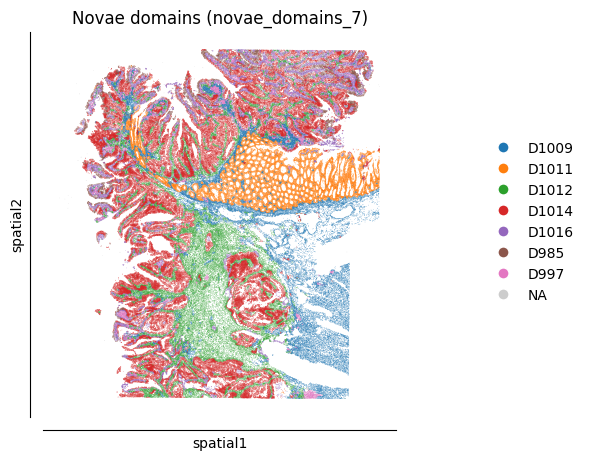

In [10]:
novae.plot.domains(adata)

Novae has a hierarchical organization of the spatial domains. That is, if you run multiple times [`assign_domains`](../../api/Novae/#novae.Novae.assign_domains) with different `level` parameters, the domains at different resolutions will be nested inside each other.

To plot the hierarchy of the domains, you can use the [`plot_domains_hierarchy`](../../api/Novae/#novae.Novae.plot_domains_hierarchy) method of Novae, as below:


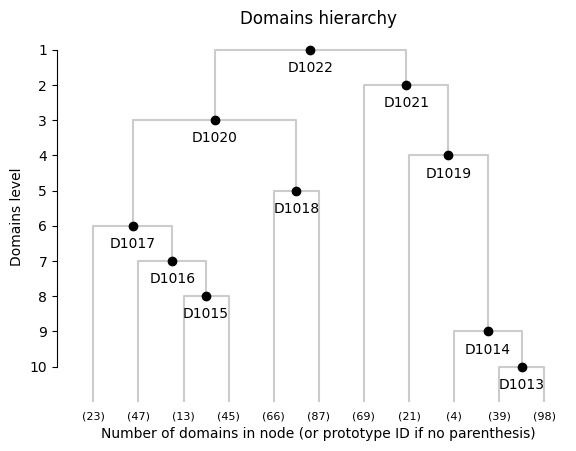

In [11]:
model.plot_domains_hierarchy()

## Multi-slide or multi-panel

You can use Novae on multiple slides or multiple panels. In that case, the input slightly changes: you can, for instance, have one `AnnData` object with a column that indicates the slide ID (if they share the same gene panel) or have a list of `AnnData` objects (one for each slide, or for each panel). For more details, refer to [this tutorial](../input_modes).

Here, we load 6 mouse brain slides. `adatas` is therefore a list of 6 `AnnData` objects.


In [10]:
adatas = novae.load_dataset(tissue="brain", species="mouse", pattern=".*months_out.*")

[INFO] (novae.data._load._hf) Found 6 h5ad file(s) matching the filters.


In [11]:
# adata object of the first slide
adatas[0]

AnnData object with n_obs × n_vars = 53913 × 346
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'slide_id', 'technology'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'log1p', 'neighbors', 'novae_tissue', 'spatial_neighbors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

### Multi-slide neighbors

When having multiple slides, computing the cells neighbors with [`novae.spatial_neighbors`](../../api/utils/#novae.spatial_neighbors) is slightly different. The multiple options are listed below and explained in more detail in [this tutorial](../input_modes).

> For this specific example, we use option 1, i.e., a list of AnnData objects, each corresponding to one slide.


In [69]:
# Option 1: Multiple AnnData objects (one per slide)
novae.spatial_neighbors(adatas, radius=80)

# Option 2: One AnnData object with multiple slides
# In that case, you need to precise the name of the column in adata.obs
# that contains the slide identifiers using `slide_key`.
novae.spatial_neighbors(adata, radius=80, slide_key="my-slide-column")

# Option 3: Multiple AnnData objects, each containing multiple slides
# Similarly, you can pass a list of AnnData objects, and precise the slide_key
novae.spatial_neighbors(adatas, radius=80, slide_key="my-slide-column")

[INFO] (novae.utils._build) Computing graph on 53,913 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils._build) Computing graph on 58,682 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils._build) Computing graph on 62,268 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils._build) Computing graph on 58,685 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils._build) Computing graph on 58,231 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils._build) Computing graph on 59,935 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)


Again, we can show the cells connectivites. See [the above explanations](./#compute-the-cells-neighbors) to understand how to perform quality controls based on this plot.


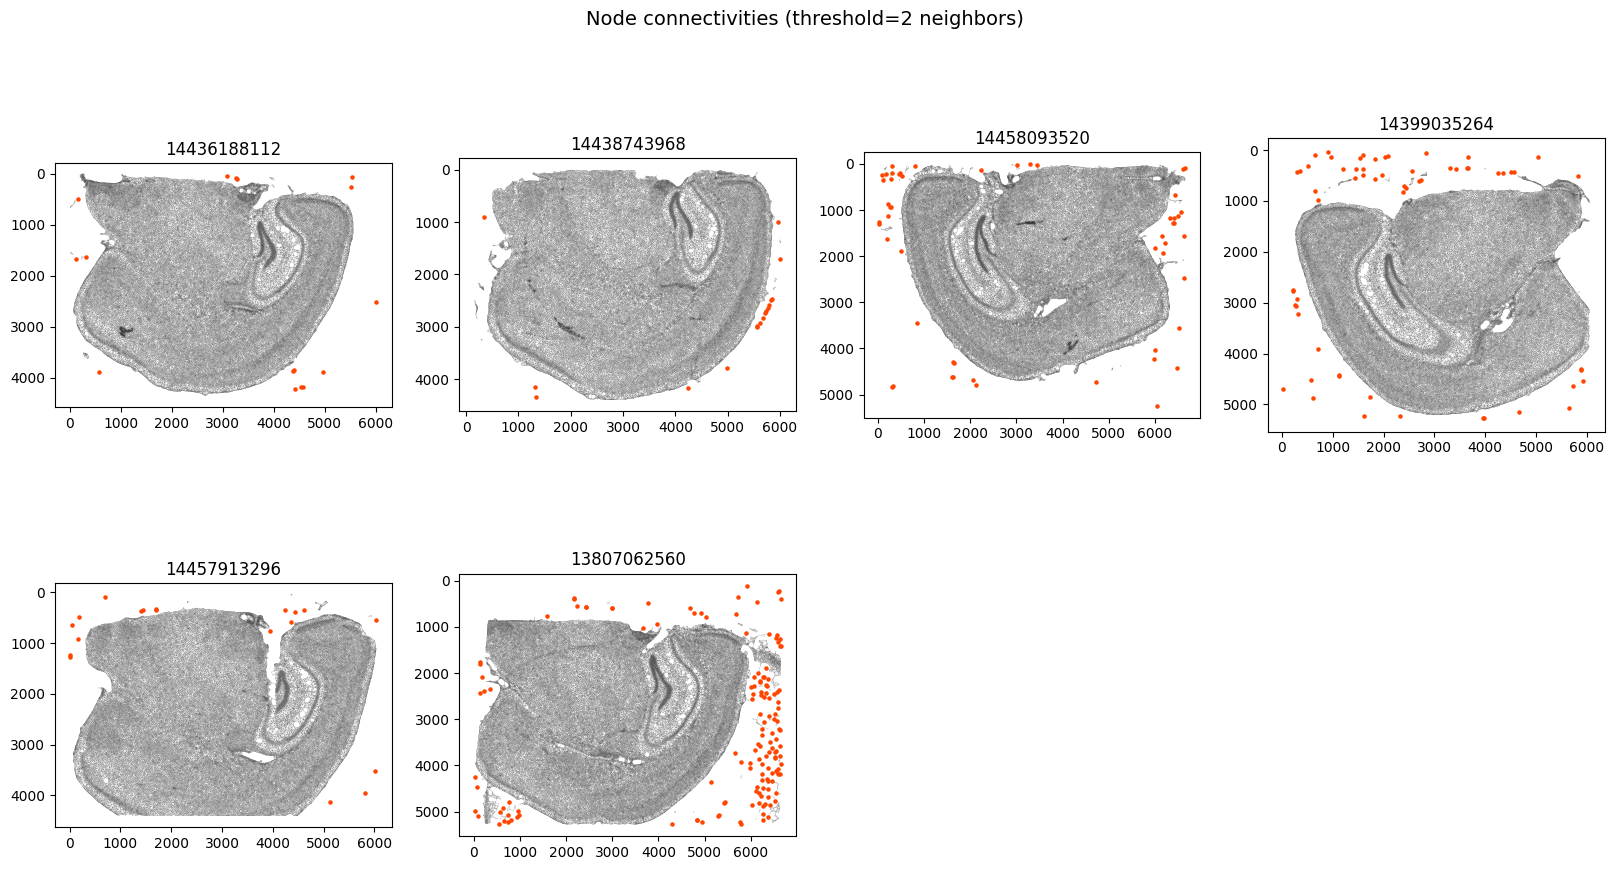

In [70]:
novae.plot.connectivities(adatas)

### Multi-slide inference


Since we are now working on mouse brain data, we'll load the brain model, as shown below.

> ℹ️ Reminder: for human tissues, you can use the `"prism-oncology/novae-human-0"` model. As stated above, other model names can be found [here](https://huggingface.co/collections/prism-oncology/novae).


In [8]:
model = novae.Novae.from_pretrained("prism-oncology/novae-brain-0")
model

Novae model
   ├── Known genes: 60697
   ├── Parameters: 32.1M
   ├── Model name: prism-oncology/novae-brain-0
   ├── Trained: True
   └── Multimodal: False

Then, the usage of Novae is similar to above, and you can again use zero-shot or fine-tuning (see the first section of this tutorial for more details).


In [72]:
# Option 1: zero-shot
model.compute_representations(adatas, zero_shot=True)

# Option 2: fine-tuning
model.fine_tune(adatas)
model.compute_representations(adatas)

Computing representations:   0%|          | 0/106 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/115 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/122 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/115 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/114 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/117 [00:00<?, ?it/s]

Again, the command line to assign domains is the same. Here, we assigned 15 domains.


In [73]:
model.assign_domains(adatas, level=15)

'novae_domains_15'

And, again, we can show the domains:

> Here, we added the `slide_name_key` argument, which is optional and used to display the name of each slide ( `slide_name_key` should be a column name of `adata.obs`).


[INFO] (novae.utils._validate) Using obs_key='novae_domains_15' as default.


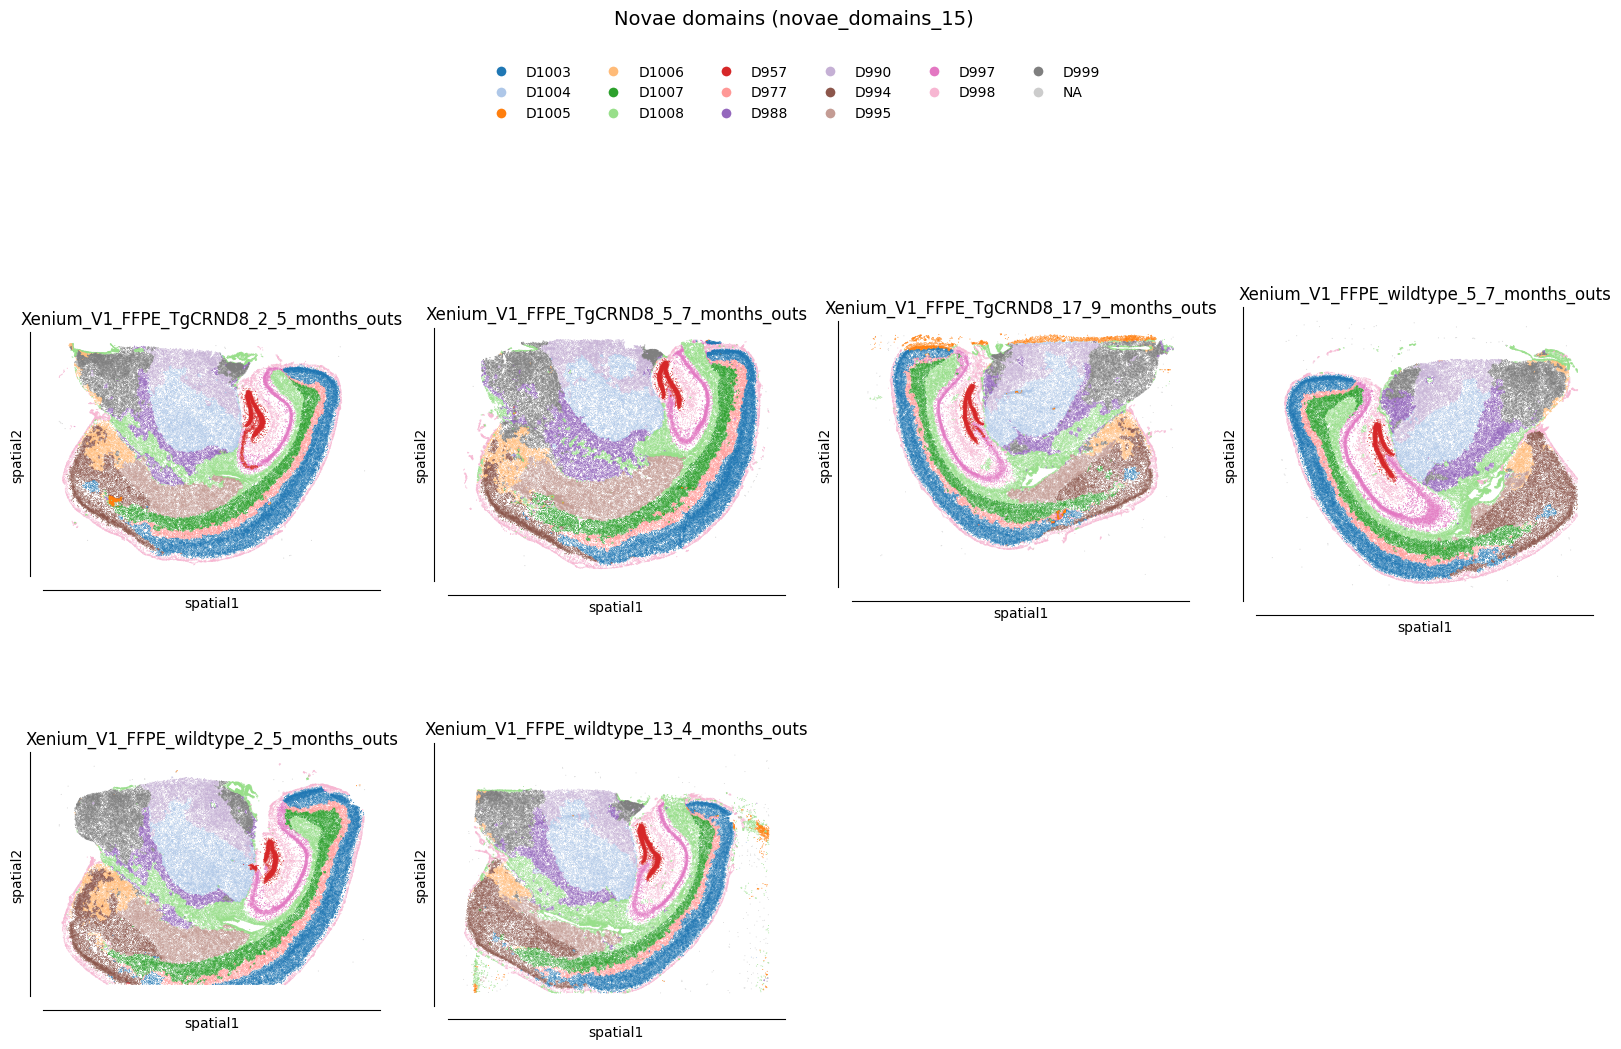

In [75]:
novae.plot.domains(adatas, slide_name_key="slide_id", cell_size=20)

## Batch-effect correction of the spatial representations

The spatial representations of each cell are stored in `adata.obsm["novae_latent"]`, and they are not batch-effect corrected by default. Yet, the (categorical) spatial domains **are** corrected. Therefore, we can use the categorical spatial domains to correct the representations, using the [`batch_effect_correction`](../../api/Novae/#novae.Novae.batch_effect_correction) method, as below:


In [76]:
model.batch_effect_correction(adatas)

[INFO] (novae.utils._validate) Using obs_key='novae_domains_15' as default.


This saved the corrected representations inside `adata.obsm["novae_latent_corrected"]`. You can use these corrected representations for further analysis.

Note that this representation is a **spatial domain representation** of each cell, not a **cell expression** representation. Indeed, it contains information on the local neighborhoods of the cells.


## Downstream analysis

Novae can also perform downstream analysis. We illustrated it below.

### Domains proportion per slide

A first simple thing to do is to look at the proportion of each domain for each slide. For instance, you may be interested in finding domains that are more or less present under certain conditions or diseases.

> Again, the `slide_name_key` is optional and is only used to show the slide's names.

Here, on our mouse brain slides, we see homogeneous domain proportions (which is expected in this very specific case).


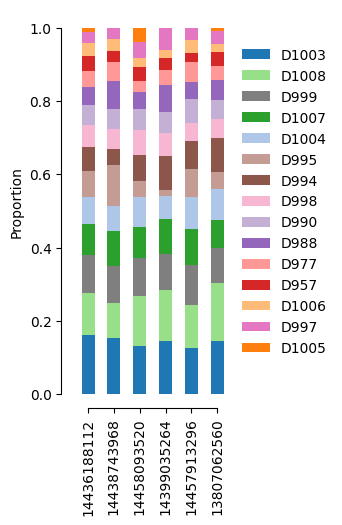

In [77]:
novae.plot.domains_proportions(adatas, obs_key="novae_domains_15")

### Slide architecture

We run trajectory inference (PAGA) on the spatial domains to extract a graph representing the "architecture" of a slide, or the "spatial domains organization".

> Currently, this function only supports one slide per call.


[INFO] (novae.utils._validate) Using obs_key='novae_domains_15' as default.


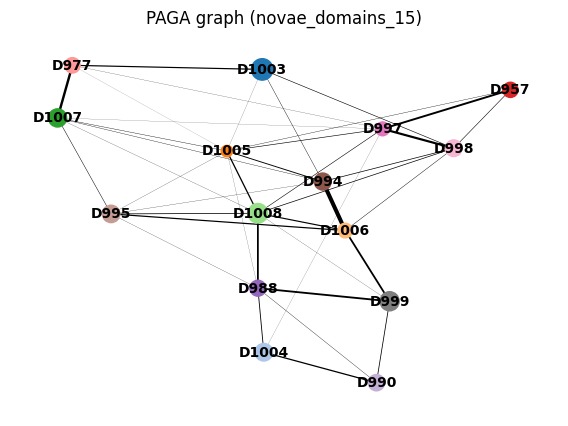

In [78]:
novae.plot.paga(adatas[0])

### Spatially Variable Genes (SVG)

To extract SVG, we run DEGs on the categorical spatial domains. The function below shows the 3 most variable genes.


[INFO] (novae.utils._validate) Using obs_key='novae_domains_15' as default.


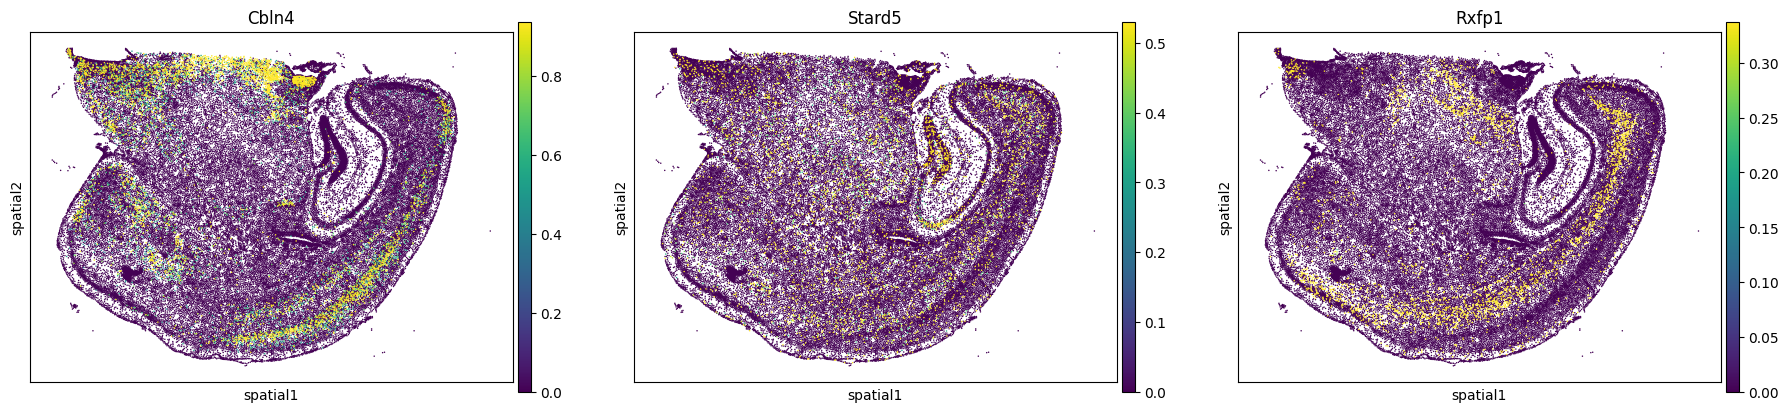

In [79]:
novae.plot.spatially_variable_genes(adatas[0], top_k=3, vmax="p95", cell_size=20)

### Spatial pathway analysis

#### Scores per domain

We can score pathways for each domain using [`scanpy.tl.score_genes`](https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.score_genes.html).

The pathways input should be one of the following:

- a JSON file downloaded from the [GSEA website](https://www.gsea-msigdb.org/gsea/msigdb/index.jsp).
- a `dict` whose keys are pathway names, and values are lists of genes (case insensitive).

> Currently, this function only supports one slide per call.


[INFO] (novae.utils._validate) Using obs_key='novae_domains_15' as default.
[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
[INFO] (novae.plot._heatmap) Plot mode: 24 pathways scores per domain


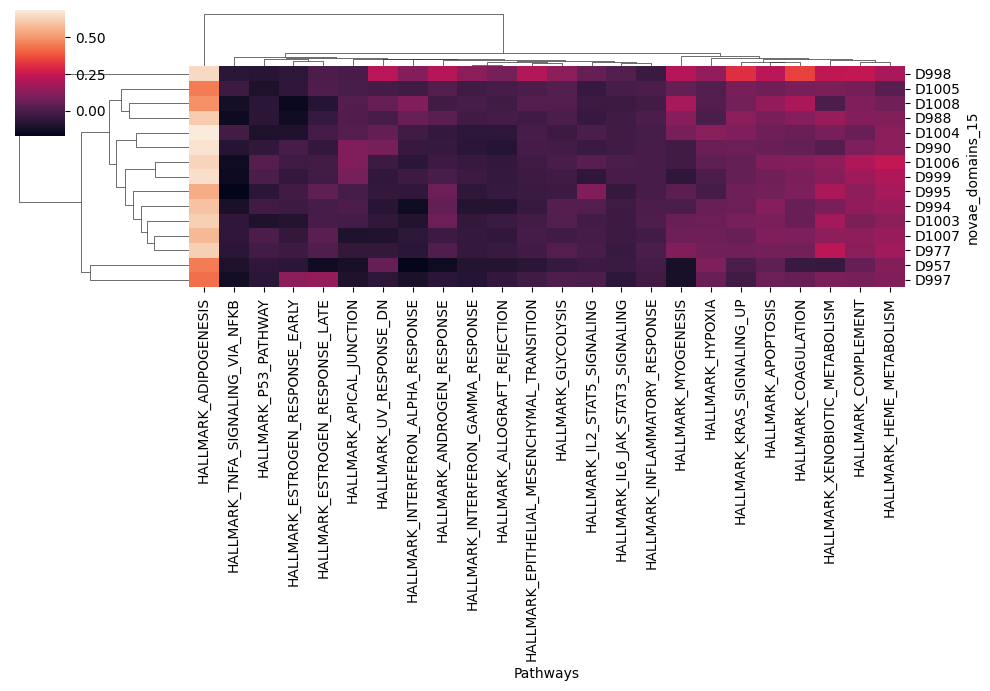

In [80]:
novae.plot.pathway_scores(adatas[0], pathways="mouse_hallmarks.json", figsize=(10, 7))

#### Scores per slide per domain

We can also show the score of one pathway, for each slide and each domain, as in the article.

Here, we need to concatenate our AnnData object into a single one. If you already have one `AnnData` object with multiple slides, you can skip this step (just ensure you provided `slide_key` in `novae.utils.spatial_neighbors`).


In [81]:
import anndata

adata_conc = anndata.concat(adatas)

Since the JSON file below contains only one pathway, it will detect that it must plot this pathway score per domain and slide. You can also force this behavior by providing the `pathway_name` argument.


[INFO] (novae.utils._validate) Using obs_key='novae_domains_15' as default.
[INFO] (novae.plot._heatmap) Loaded 1 pathway(s)
[INFO] (novae.plot._heatmap) Plot mode: LEE_AGING_CEREBELLUM_UP score per domain per slide


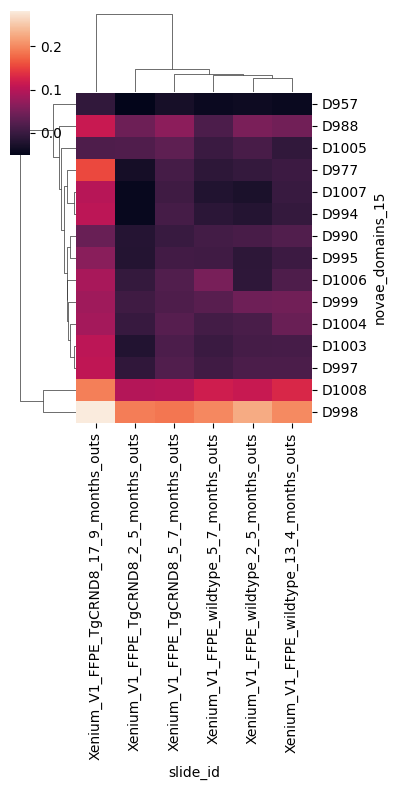

In [87]:
novae.plot.pathway_scores(
    adata_conc, pathways="LEE_AGING_CEREBELLUM_UP.json", figsize=(4, 8), slide_name_key="slide_id"
)